<a href="https://colab.research.google.com/github/ehsankarami1358/LOKA_HYDRO/blob/main/LOKA_U2_hillchart_my.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata, RBFInterpolator
from scipy.ndimage import gaussian_filter
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler


In [130]:
df=pd.read_csv('u2_MW_OP_FL_L_28_1_2026_26_2_2026_R2.csv')
df.head()

,Timestamp,ACTIVE_POWER(MW),OPPENING(%),FLOW(m3/s),HEAD_L(m),TAIL_L(m),SPEED(RPM)
0,1/28/2026 9:51,-0.162165,0.056062,50.42088,1092.866064,1008.827024,0.000000
1,1/28/2026 10:20,-0.163380,0.057351,50.48284,1092.867064,1008.830024,0.000000
2,1/28/2026 11:05,-0.163995,0.051196,50.38436,1092.873064,1008.826024,0.000000
3,1/28/2026 11:50,-0.173843,0.050916,50.36597,1092.877064,1008.813024,0.000933
4,1/28/2026 12:35,-0.176920,0.052595,50.28548,1092.879064,1008.820024,0.000000


In [131]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [132]:
df.dropna(subset=['Timestamp'], inplace=True)

In [133]:
df['Net_Head'] = df['HEAD_L(m)'] - df['TAIL_L(m)']

In [134]:
df.rename(columns={'FLOW(m3/s)': 'FLOW',
                   'ACTIVE_POWER(MW)': 'ACTIVE_POWER',
                   'HEAD_L(m)': 'HEAD_L',
                   'TAIL_L(m)': 'TAIL_L',
                   'Net_Head': 'Net_Head',
                   'SPEED(%)': 'SPEED',
                   'OPPENING(%)': 'OPPENING'
                   }, inplace=True)

In [135]:
# Calculate efficiency
electrical_efficiency = 0.98
df['Efficiency'] = (df['ACTIVE_POWER'] * 1000) / (9.81 * df['FLOW'] * df['Net_Head'])
df['Efficiency']=df['Efficiency']/electrical_efficiency

In [136]:
df_actual = df[(df['ACTIVE_POWER'] > 1) & (df['FLOW'] > 1) & (df['Efficiency'] > 0.7) & (df['Efficiency'] < 0.99)].copy()

In [137]:
df_actual.head()

,Timestamp,ACTIVE_POWER,OPPENING,FLOW,HEAD_L,TAIL_L,SPEED(RPM),Net_Head,Efficiency
20,2026-01-29 00:36:00,117.9393,70.77856,159.2610,1092.819064,1010.056024,166.7670,82.76304,0.930717
21,2026-01-29 01:21:00,108.9977,66.78220,149.8594,1092.858064,1009.974024,166.8099,82.88404,0.912783
22,2026-01-29 02:06:00,111.3907,67.84278,152.3051,1092.818064,1009.995024,166.7791,82.82304,0.918519
23,2026-01-29 02:51:00,105.3012,65.30732,145.8360,1092.857064,1009.946024,166.7791,82.91104,0.905860
24,2026-01-29 03:36:00,117.2180,70.25710,158.1096,1092.837064,1010.064024,166.7800,82.77304,0.931648


In [138]:
print(f"Total data points: {len(df)}")
print(f"Actual data points: {len(df_actual)}")
print(f"maximum head: {df['ACTIVE_POWER'].max() :.2f}")
print(f"maximum efficiency: {df_actual['Efficiency'].max() :.2f}")
print(f"minimum efficiency: {df_actual['Efficiency'].min() :.2f}")

Total data points: 939
Actual data points: 896
maximum head: 141.52
maximum efficiency: 0.94
minimum efficiency: 0.84


<Axes: xlabel='ACTIVE_POWER', ylabel='FLOW'>

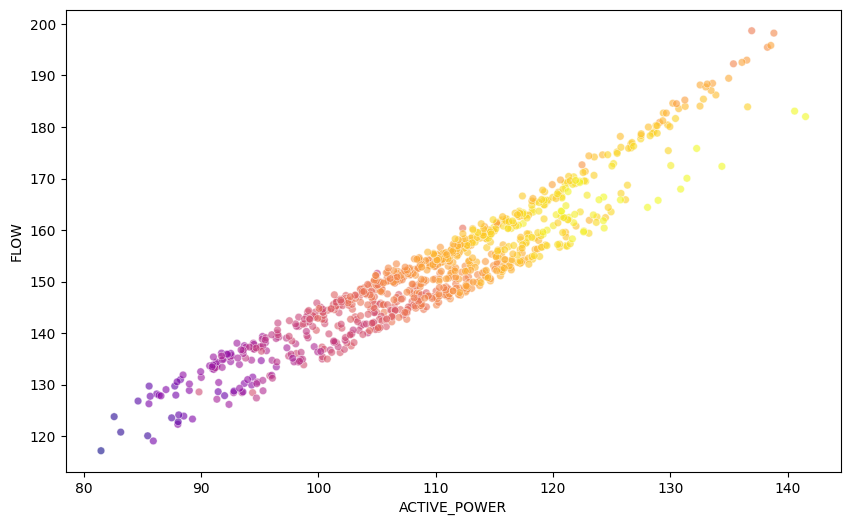

In [139]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df_actual, x='ACTIVE_POWER', y='FLOW', c=df_actual['Efficiency'], s=30, alpha=0.6, cmap='plasma',
                           vmin=0.85, vmax=0.94)

<Axes: xlabel='OPPENING', ylabel='FLOW'>

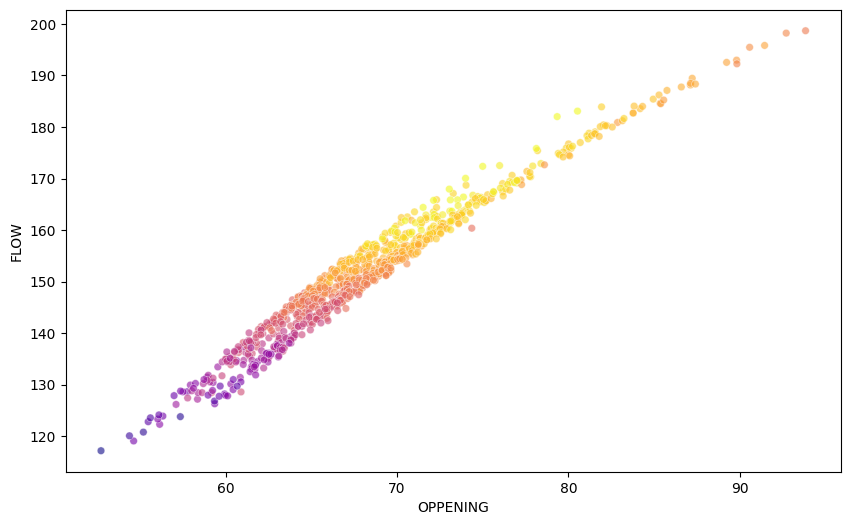

In [140]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df_actual, x='OPPENING', y='FLOW', c=df_actual['Efficiency'], s=30, alpha=0.6, cmap='plasma',
                           vmin=0.85, vmax=0.94)

CALCULATION OF HILLCHART

Unit Speed (N11 or n11):

Formula: N11 = N * D / sqrt(H)

Meaning: The hypothetical speed (in RPM) the turbine would run at if it had a 1-meter diameter under a 1-meter net head. It normalizes the rotational speed for head.

Unit Discharge (Q11 or q11):

Formula: Q11 = Q / (D² * sqrt(H))

Meaning: The hypothetical flow rate the turbine would pass if it had a 1-meter diameter under a 1-meter net head. It normalizes the flow for head and size.
# Unit power: P11 = P / (D² * H^(3/2))
	​


In [141]:

# Calculate unit parameters
# Unit discharge: Q11 = Q / (D² * √H)
# Unit power: P11 = P / (D² * H^(3/2))
# Relative unit speed (since speed is constant): n11_rel = 1/√H
# Normalize to design head
# Specific energy (kWh per m³ of water)

# Your turbine specifications
DESIGN_HEAD = 90.5      # meters
RUNNER_DIAMETER = 4.2  # meters
RUNNER_AREA = RUNNER_DIAMETER ** 2

df_actual['sqrt_H'] = np.sqrt(df_actual['Net_Head'])
df_actual['H_32'] = df_actual['Net_Head'] ** 1.5
df_actual['P11'] = df_actual['ACTIVE_POWER'] / (RUNNER_AREA * df_actual['H_32'])
df_actual['Specific_Energy'] = df_actual['ACTIVE_POWER'] * 1000 /df_actual['FLOW']
df_actual['N11'] = (df_actual['SPEED(RPM)'] * 375) / (np.sqrt(df_actual['Net_Head']))
df_actual['Q11'] = df_actual['FLOW'] / (np.sqrt(df_actual['Net_Head']))

In [142]:
df_best_bep = df_actual.sort_values(by='Efficiency', ascending=False).head(5)
display(df_best_bep[['Timestamp', 'ACTIVE_POWER', 'OPPENING', 'SPEED(RPM)', 'Net_Head', 'FLOW', 'Efficiency']])

,Timestamp,ACTIVE_POWER,OPPENING,SPEED(RPM),Net_Head,FLOW,Efficiency
276,2026-02-05 23:04:00,134.3890,74.99791,166.8043,85.96004,172.3616,0.943477
266,2026-02-05 15:33:00,128.0515,71.52021,166.8229,85.90204,164.3987,0.943165
289,2026-02-06 08:49:00,130.8734,73.04798,166.7520,86.01504,167.9467,0.942346
275,2026-02-05 22:18:00,141.5192,79.34508,166.7744,85.86504,182.0156,0.941879
246,2026-02-05 00:32:00,128.9525,72.12897,166.7371,85.93504,165.7661,0.941605


In [143]:
# ============================================
# 4. FIND BEST EFFICIENCY POINT (BEP)
# ============================================
bep_idx = df_actual['Efficiency'].idxmax()
bep_row = df_actual.loc[bep_idx]
print(f"Best Efficiency Point (BEP):\n{bep_row}")
print(f"Opening: {bep_row['OPPENING']:.1f}%")
print(f"ACTIVE_POWER: {bep_row['ACTIVE_POWER']:.1f} MW")
print(f"SPEED(RPM): {bep_row['SPEED(RPM)']:.1f} RPM")

Best Efficiency Point (BEP):
Timestamp          2026-02-05 23:04:00
ACTIVE_POWER                   134.389
OPPENING                      74.99791
FLOW                          172.3616
HEAD_L                     1096.141064
TAIL_L                     1010.181024
SPEED(RPM)                    166.8043
Net_Head                      85.96004
Efficiency                    0.943477
sqrt_H                        9.271464
H_32                        796.975394
P11                           0.009559
Specific_Energy             779.692228
N11                        6746.681453
Q11                          18.590549
Name: 276, dtype: object
Opening: 75.0%
ACTIVE_POWER: 134.4 MW
SPEED(RPM): 166.8 RPM


In [144]:
# ============================================
# 4. FIND BEST EFFICIENCY POINT (BEP)
# ============================================
bep_idx = df_actual['Efficiency'].idxmax()
bep_row = df_actual.loc[bep_idx]
print(f"Best Efficiency Point (BEP):\n{bep_row}")
print(f"Opening: {bep_row['OPPENING']:.1f}%")
print(f"ACTIVE_POWER: {bep_row['ACTIVE_POWER']:.1f} MW")
print(f"SPEED(RPM): {bep_row['SPEED(RPM)']:.1f} RPM")

Best Efficiency Point (BEP):
Timestamp          2026-02-05 23:04:00
ACTIVE_POWER                   134.389
OPPENING                      74.99791
FLOW                          172.3616
HEAD_L                     1096.141064
TAIL_L                     1010.181024
SPEED(RPM)                    166.8043
Net_Head                      85.96004
Efficiency                    0.943477
sqrt_H                        9.271464
H_32                        796.975394
P11                           0.009559
Specific_Energy             779.692228
N11                        6746.681453
Q11                          18.590549
Name: 276, dtype: object
Opening: 75.0%
ACTIVE_POWER: 134.4 MW
SPEED(RPM): 166.8 RPM


In [145]:
print(f"Q11 range: {df_actual['Q11'].min():.3f} to {df_actual['Q11'].max():.3f}")
print(f"N11 range: {df_actual['N11'].min():.3f} to {df_actual['N11'].max():.3f}")
print(f"Average efficency range: {df_actual['Efficiency'].mean():.3f}")
print(f"Specific Energy range: {df_actual['Specific_Energy'].min():.3f} to {df_actual['Specific_Energy'].max():.3f} kWh/m³")

Q11 range: 12.613 to 22.394
N11 range: 6709.055 to 7049.403
Average efficency range: 0.913
Specific Energy range: 659.651 to 779.692 kWh/m³


In [146]:
print(f"Q11 range: {df_actual['Q11'].min():.3f} to {df_actual['Q11'].max():.3f}")
print(f"N11 range: {df_actual['N11'].min():.3f} to {df_actual['N11'].max():.3f}")
print(f"Average efficency range: {df_actual['Efficiency'].mean():.3f}")
print(f"Specific Energy range: {df_actual['Specific_Energy'].min():.3f} to {df_actual['Specific_Energy'].max():.3f} kWh/m³")

Q11 range: 12.613 to 22.394
N11 range: 6709.055 to 7049.403
Average efficency range: 0.913
Specific Energy range: 659.651 to 779.692 kWh/m³


In [147]:
# ============================================
# 4. FIND BEST EFFICIENCY POINT (BEP)
# ============================================
bep_idx = df_actual['Efficiency'].idxmax()
bep_row = df_actual.loc[bep_idx]
print(f"Best Efficiency Point (BEP):\n{bep_row}")
print(f"Opening: {bep_row['OPPENING']:.1f}%")
print(f"ACTIVE_POWER: {bep_row['ACTIVE_POWER']:.1f} MW")
print(f"SPEED(RPM): {bep_row['SPEED(RPM)']:.1f} RPM")


Best Efficiency Point (BEP):
Timestamp          2026-02-05 23:04:00
ACTIVE_POWER                   134.389
OPPENING                      74.99791
FLOW                          172.3616
HEAD_L                     1096.141064
TAIL_L                     1010.181024
SPEED(RPM)                    166.8043
Net_Head                      85.96004
Efficiency                    0.943477
sqrt_H                        9.271464
H_32                        796.975394
P11                           0.009559
Specific_Energy             779.692228
N11                        6746.681453
Q11                          18.590549
Name: 276, dtype: object
Opening: 75.0%
ACTIVE_POWER: 134.4 MW
SPEED(RPM): 166.8 RPM


In [148]:
df_best_bep = df_actual.sort_values(by='Efficiency', ascending=False).head(5)
display(df_best_bep[['Timestamp', 'ACTIVE_POWER', 'OPPENING', 'SPEED(RPM)', 'Net_Head', 'FLOW', 'Efficiency']])

,Timestamp,ACTIVE_POWER,OPPENING,SPEED(RPM),Net_Head,FLOW,Efficiency
276,2026-02-05 23:04:00,134.3890,74.99791,166.8043,85.96004,172.3616,0.943477
266,2026-02-05 15:33:00,128.0515,71.52021,166.8229,85.90204,164.3987,0.943165
289,2026-02-06 08:49:00,130.8734,73.04798,166.7520,86.01504,167.9467,0.942346
275,2026-02-05 22:18:00,141.5192,79.34508,166.7744,85.86504,182.0156,0.941879
246,2026-02-05 00:32:00,128.9525,72.12897,166.7371,85.93504,165.7661,0.941605


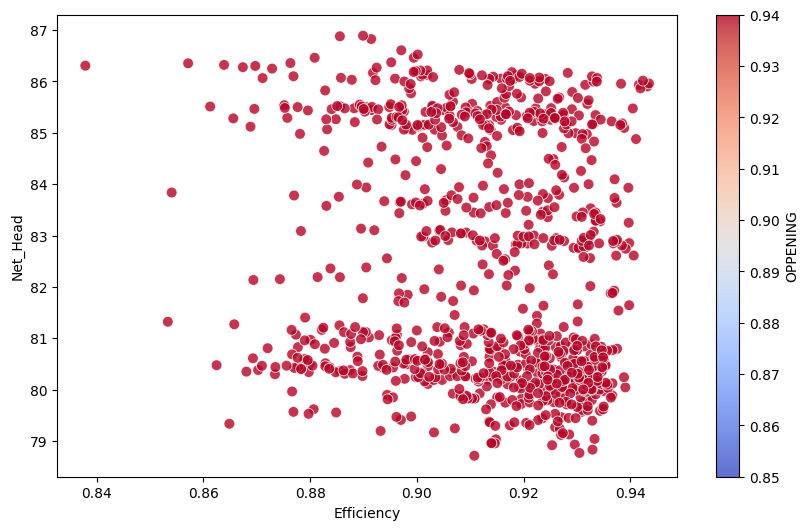

In [149]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df_actual, x='Efficiency', y='Net_Head', c=df_actual['OPPENING'], s=60, alpha=0.8,
                cmap='coolwarm', vmin=0.85, vmax=0.94)
plt.colorbar(ax.collections[0], label='OPPENING')

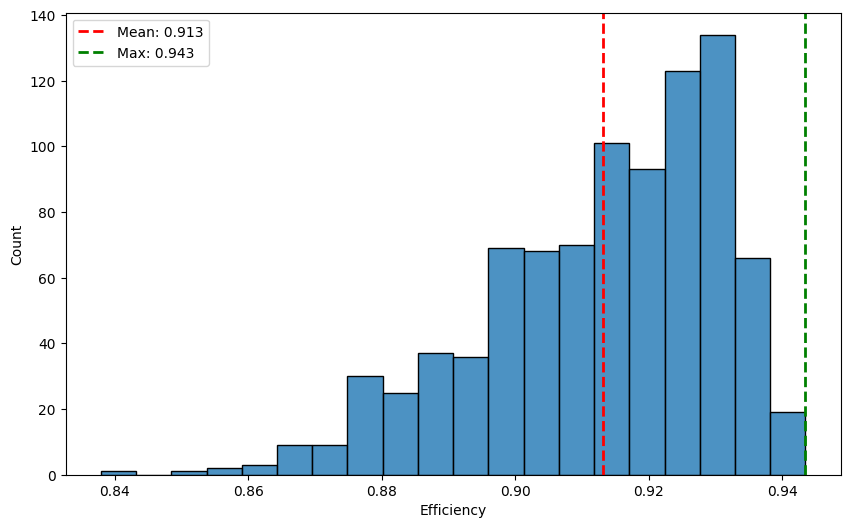

In [150]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=df_actual, x='Efficiency',alpha=0.8)
plt.axvline(df_actual['Efficiency'].mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {df_actual['Efficiency'].mean():.3f}')
plt.axvline(df_actual['Efficiency'].max(), color='green', linestyle='--', linewidth=2,
                   label=f'Max: {df_actual['Efficiency'].max():.3f}')
plt.legend()

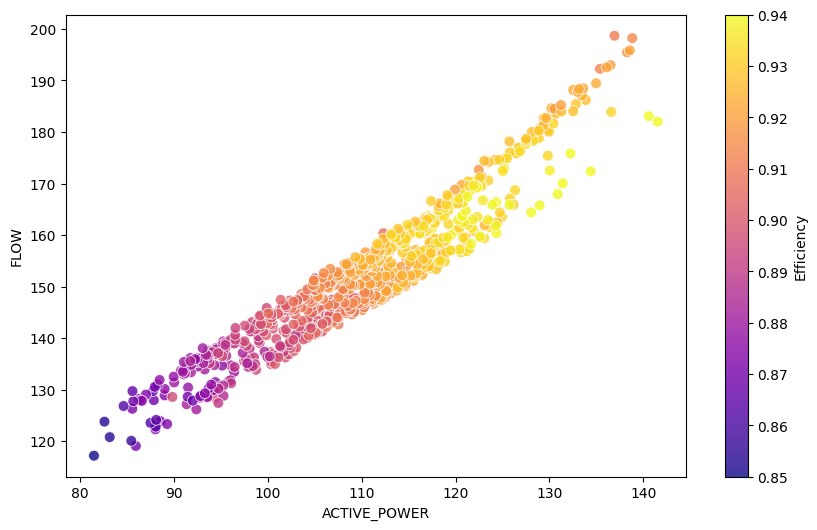

In [151]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df_actual, x='ACTIVE_POWER', y='FLOW', c=df_actual['Efficiency'], s=60, alpha=0.8,
                cmap='plasma', vmin=0.85, vmax=0.94)
plt.colorbar(ax.collections[0], label='Efficiency')

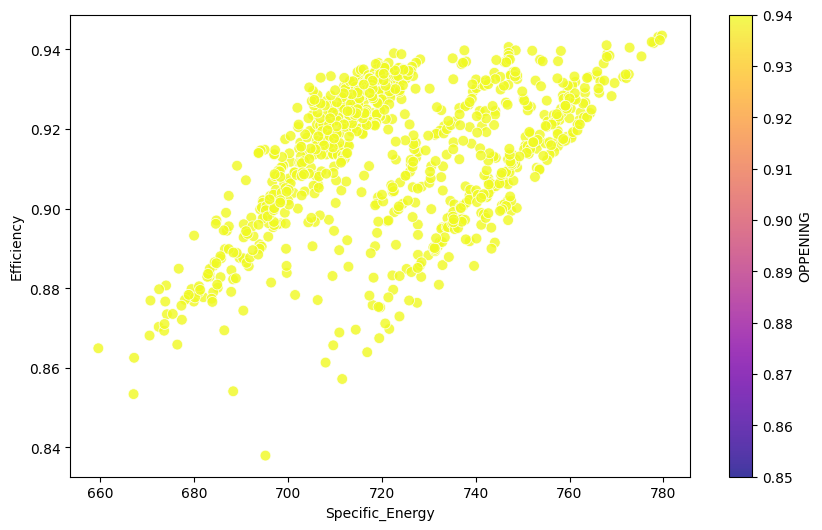

In [152]:
fig, ax = plt.subplots(figsize=(10, 6))
b = sns.scatterplot(data=df_actual, x='Specific_Energy', y='Efficiency', c=df_actual['OPPENING'], s=60, alpha=0.8,
                cmap='plasma', vmin=0.85, vmax=0.94, ax=ax)
plt.colorbar(ax.collections[0], label='OPPENING')

In [153]:
average_efficiency = df_actual['Efficiency'].mean()
print(f"Average Efficiency: {average_efficiency:.3f}")
average_specific_energy = df_actual['Specific_Energy'].mean()
print(f"Average Specific Energy: {average_specific_energy:.3f} kWh/m³")
average_power = df_actual['ACTIVE_POWER'].mean()
print(f"Average Power: {average_power:.3f} MW")
average_flow = df_actual['FLOW'].mean()
print(f"Average Flow: {average_flow:.3f} m³/s")
average_OPPENING = df_actual['OPPENING'].mean()
print(f"Average OPPENING: {average_OPPENING:.3f}%")

Average Efficiency: 0.913
Average Specific Energy: 722.845 kWh/m³
Average Power: 109.651 MW
Average Flow: 151.613 m³/s
Average OPPENING: 68.146%
